# Análisis Estadístico de Resultados de Aprendizaje Federado

Este notebook realiza el análisis estadístico comparativo para las estrategias de aprendizaje federado frente al modelo centralizado (**Proactive Forest Centralizado**), utilizando los resultados consolidados de **Accuracy** y **PCD** para 10 bases de datos definidos en el archivo `tablas.md`.

### Metodología de Análisis:
1. **Test de Friedman**: Prueba global no paramétrica de diferencias. Si el p-valor es mayor o igual a 0.05, se concluye que no hay significancia estadística y se interrumpe el análisis de la métrica correspondiente.
2. **Análisis Post-hoc con Ajuste de Holm**: Si la prueba de Friedman es significativa (p < 0.05), se ejecuta una comparación por parejas utilizando el test de rangos con signo de Wilcoxon contra el baseline (`PF Cent.`). Para evitar la inflación de la Tasa de Error por Familia (FWER), se aplica la corrección secuencial de Holm sobre los p-valores obtenidos.

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

## 1. Función para parsear el archivo `tablas.md`

In [2]:
def parse_markdown_tables(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f'No se encontró el archivo: {filepath}')
        
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    tables = {}
    current_table_name = None
    table_lines = []
    
    def parse_lines_to_df(t_lines):
        header_line = t_lines[0]
        headers = [h.strip().replace('**', '') for h in header_line.split('|')[1:-1]]
        
        data = []
        for line in t_lines[2:]:
            row = [cell.strip().replace('**', '') for cell in line.split('|')[1:-1]]
            if row:
                data.append(row)
                
        df = pd.DataFrame(data, columns=headers)
        df = df.set_index(headers[0])
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    for line in lines:
        line_str = line.strip()
        if line_str.startswith('**Tabla'):
            if current_table_name and table_lines:
                tables[current_table_name] = parse_lines_to_df(table_lines)
                table_lines = []
            if 'Exactitud' in line_str or 'accuracy' in line_str.lower():
                current_table_name = 'Accuracy'
            elif 'PCD' in line_str:
                current_table_name = 'PCD'
            else:
                current_table_name = line_str
        elif line_str.startswith('|'):
            table_lines.append(line_str)
            
    if current_table_name and table_lines:
        tables[current_table_name] = parse_lines_to_df(table_lines)
        
    return tables

## 2. Cargar tablas y definir funciones para el análisis y visualización

In [3]:
possible_paths = [
    'tablas.md',
    '../tablas.md',
    os.path.join('scripts', 'tablas.md'),
    os.path.join('..', 'tablas.md')
]
filepath = None
for path in possible_paths:
    if os.path.exists(path):
        filepath = path
        break

if filepath:
    print(f'Cargando datos desde: {filepath}')
    tables = parse_markdown_tables(filepath)
    # Excluir 'Local' de todos los DataFrames
    for name in tables:
        if 'Local' in tables[name].columns:
            tables[name] = tables[name].drop(columns=['Local'])
    print('Tablas cargadas con éxito (excluyendo la estrategia Local):', list(tables.keys()))
else:
    print('Error: No se pudo localizar tablas.md')

Cargando datos desde: ../tablas.md
Tablas cargadas con éxito (excluyendo la estrategia Local): ['Accuracy', '**Tabla 3.4. Resultados de eficacia (Macro-F1) de todas las estrategias federadas frente al modelo centralizado.**', 'PCD']


In [4]:
def analyze_metric(metric_name, df):
    baseline_col = 'PF Cent.'
    if baseline_col not in df.columns:
        raise ValueError(f'La columna de baseline {baseline_col} no se encuentra en el DataFrame.')
        
    strategies = [col for col in df.columns if col != baseline_col]
    columns_friedman = [df[baseline_col].values] + [df[strat].values for strat in strategies]
    
    print('=' * 80)
    print(f'--- ANÁLISIS ESTADÍSTICO PARA LA MÉTRICA: {metric_name} ---')
    print('=' * 80)
    print(f'Datasets analizados ({len(df.index)}): {', '.join(df.index)}\n')
    
    # Friedman Test
    stat_global, p_friedman_global = friedmanchisquare(*columns_friedman)
    print('PASO 1: Test de Friedman (Diferencias Globales)')
    print(f'  Estadístico: {stat_global:.4f}')
    print(f'  p-value: {p_friedman_global:.6e}')
    
    if p_friedman_global >= 0.05:
        print('  Conclusión: NO existen diferencias globales estadísticamente significativas (p >= 0.05).')
        print('  El análisis de esta métrica se detiene aquí. No procede realizar el análisis post-hoc.')
        print('=' * 80 + '\n')
    else:        
        print('  Conclusión: EXISTEN diferencias significativas globales (p < 0.05).')
        print('-' * 80)
    
    # Wilcoxon Tests
    print('PASO 2: Análisis Post-hoc con Ajuste de Holm (Centralizado vs Cada Estrategia)')
    print(f'{'Estrategia':<25} | {'Mean ' + metric_name:<12} | {'p-value raw':<12} | {'p-value Holm':<12} | {'Diferencia':<10} | {'Significativa':<12}')
    print('-' * 80)
    
    mean_cent = df[baseline_col].mean()
    
    # Calcular y almacenar p-valores crudos de Wilcoxon
    raw_p_values = []
    for strat in strategies:
        try:
            _, p_w = wilcoxon(df[baseline_col].values, df[strat].values)
            raw_p_values.append(p_w)
        except Exception as e:
            raw_p_values.append(1.0)
            
    # Ajuste de Holm
    reject, p_adjusted, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')
    
    # Emparejar resultados
    results = []
    for i, strat in enumerate(strategies):
        mean_strat = df[strat].mean()
        diff = mean_strat - mean_cent
        results.append({
            'strat': strat,
            'mean': mean_strat,
            'p_raw': raw_p_values[i],
            'p_holm': p_adjusted[i],
            'diff': diff,
            'sig': 'Sí (p<0.05)' if reject[i] else 'No'
        })
        
    # Imprimir baseline
    print(f'{'* ' + baseline_col + ' *':<25} | {mean_cent:.6f} | {'-':<12} | {'-':<12} | {'-':<10} | Baseline')
    
    # Ordenar por valor medio descendente
    sorted_results = sorted(results, key=lambda r: r['mean'], reverse=True)
    
    for r in sorted_results:
        p_raw_str = f'{r['p_raw']:.6f}' if r['p_raw'] != 1.0 else '1.000000'
        p_holm_str = f'{r['p_holm']:.6f}'
        print(f'{r['strat']:<25} | {r['mean']:.6f} | {p_raw_str:<12} | {p_holm_str:<12} | {r['diff']:+.6f} | {r['sig']:<12}')
    print('=' * 80 + '\n')

In [5]:
def plot_metric(metric_name, df):
    mean_values = df.mean().sort_values(ascending=True)
    
    colors = []
    for idx in mean_values.index:
        if idx == 'PF Cent.':
            colors.append('#FF5A5F')
        elif idx.startswith('S8_'):
            colors.append('#3A86C8')
        else:
            colors.append('#5F5AA2')
            
    fig, ax = plt.subplots(figsize=(12, 6.5), dpi=100)
    bars = ax.barh(mean_values.index, mean_values.values, color=colors, height=0.6)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    
    ax.set_title(f'Comparativa de Media de {metric_name} por Estrategia', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f'Media de {metric_name}', fontsize=11, labelpad=10)
    
    for bar in bars:
        width = bar.get_width()
        is_baseline = (bar.get_y() == mean_values.index.get_loc('PF Cent.'))
        ax.text(width + (width * 0.003), bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', 
                va='center', ha='left', fontsize=9.5,
                fontweight='bold' if is_baseline else 'normal')
                
    min_val = mean_values.min()
    max_val = mean_values.max()
    padding = (max_val - min_val) * 0.1
    ax.set_xlim(max(0, min_val - padding), max_val + padding * 1.5)
    
    plt.tight_layout()
    plt.show()

## 3. Análisis de la Exactitud (Accuracy)

In [6]:
analyze_metric('Accuracy', tables['Accuracy'])

--- ANÁLISIS ESTADÍSTICO PARA LA MÉTRICA: Accuracy ---
Datasets analizados (10): Car, Glass, Iris, Molecular, Nursery, Optdigits, Pendigits, Sonar, Spambase, Vowel

PASO 1: Test de Friedman (Diferencias Globales)
  Estadístico: 91.9977
  p-value: 2.024176e-14
  Conclusión: EXISTEN diferencias significativas globales (p < 0.05).
--------------------------------------------------------------------------------
PASO 2: Análisis Post-hoc con Ajuste de Holm (Centralizado vs Cada Estrategia)
Estrategia                | Mean Accuracy | p-value raw  | p-value Holm | Diferencia | Significativa
--------------------------------------------------------------------------------
* PF Cent. *              | 0.937810 | -            | -            | -          | Baseline
S7                        | 0.895300 | 0.001953     | 0.023438     | -0.042510 | Sí (p<0.05) 
S4                        | 0.891500 | 0.001953     | 0.023438     | -0.046310 | Sí (p<0.05) 
S6                        | 0.890990 | 0.001953  

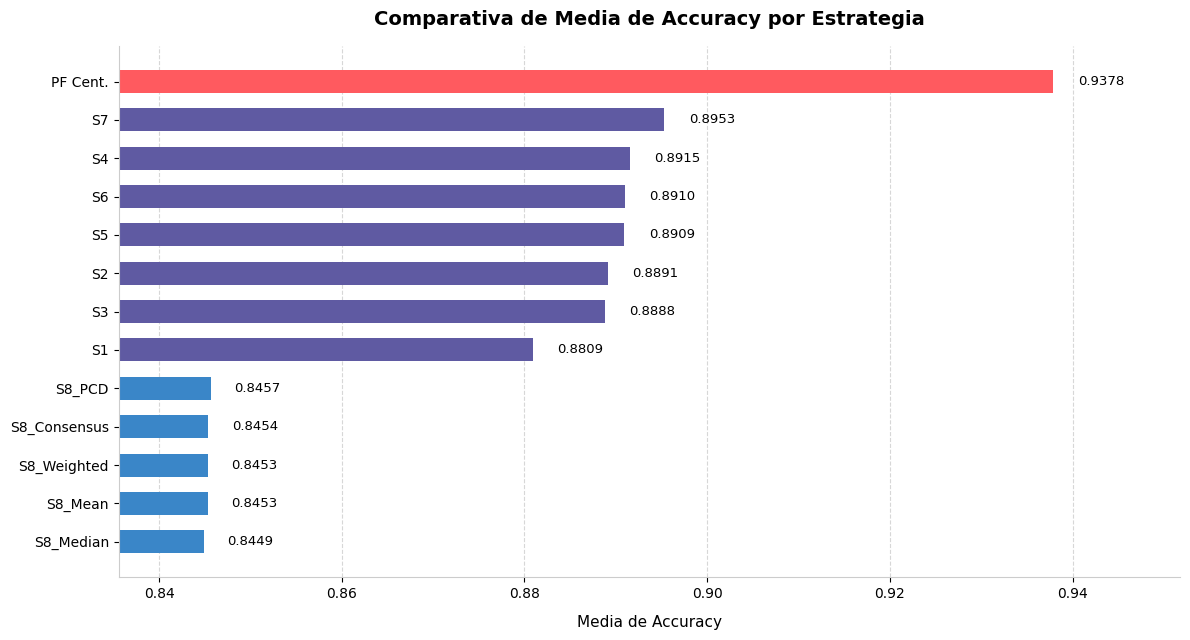

In [7]:
plot_metric('Accuracy', tables['Accuracy'])

## 4. Análisis de Diversidad Estructural (PCD)

In [8]:
analyze_metric('PCD', tables['PCD'])

--- ANÁLISIS ESTADÍSTICO PARA LA MÉTRICA: PCD ---
Datasets analizados (10): Car, Glass, Iris, Molecular, Nursery, Optdigits, Pendigits, Sonar, Spambase, Vowel

PASO 1: Test de Friedman (Diferencias Globales)
  Estadístico: 18.7281
  p-value: 9.530408e-02
  Conclusión: NO existen diferencias globales estadísticamente significativas (p >= 0.05).
  El análisis de esta métrica se detiene aquí. No procede realizar el análisis post-hoc.

PASO 2: Análisis Post-hoc con Ajuste de Holm (Centralizado vs Cada Estrategia)
Estrategia                | Mean PCD     | p-value raw  | p-value Holm | Diferencia | Significativa
--------------------------------------------------------------------------------
* PF Cent. *              | 0.561303 | -            | -            | -          | Baseline
S1                        | 0.597430 | 0.160156     | 1.000000     | +0.036127 | No          
S7                        | 0.586670 | 0.431641     | 1.000000     | +0.025367 | No          
S6                       

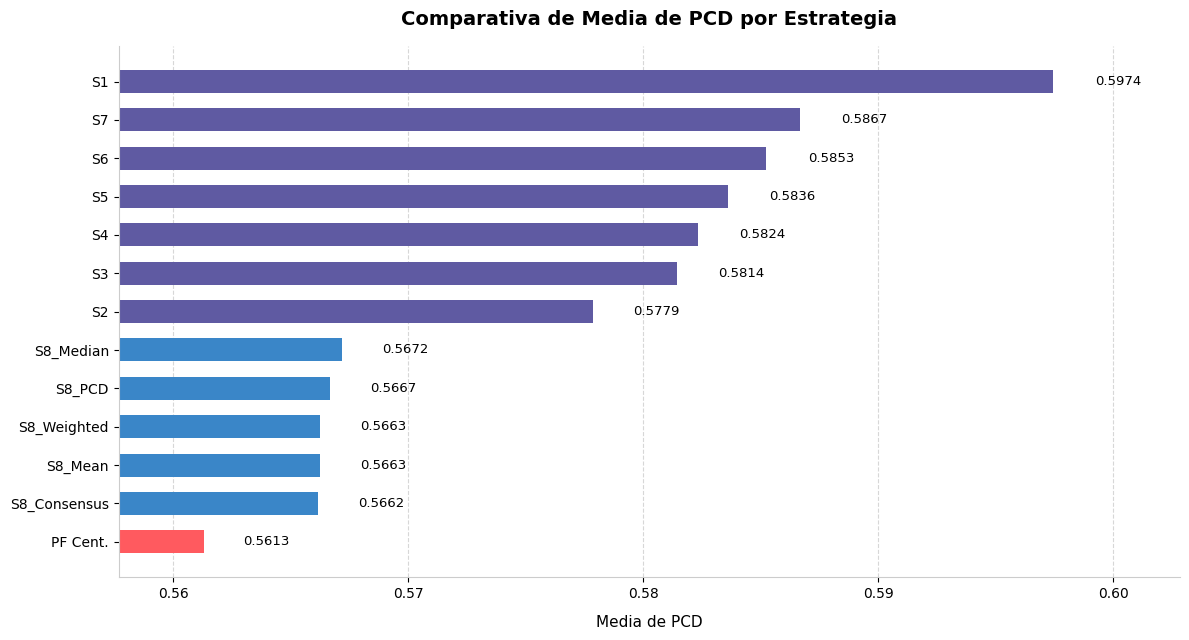

In [9]:
plot_metric('PCD', tables['PCD'])

In [10]:
from scipy.stats import wilcoxon

# Datos actualizados de accuracy
aislado_accuracy = [0.9251	,
0.6595	,
0.9289	,
0.7645	,
0.9661	,
0.9511	,
0.9742	,
0.7529	,
0.9325	,
0.7226	,
]

S7_accuracy = [0.9603	,
0.7264	,
0.9378	,
0.8397	,
0.9806	,
0.9676	,
0.9849	,
0.7598	,
0.9397	,
0.8562	,
]

# Test de Wilcoxon para la accuracy
stat_accuracy, p_value_accuracy = wilcoxon(aislado_accuracy, S7_accuracy)

# Nivel de significancia
alpha = 0.05

# Mostrar resultados y evaluar las hipótesis
print("\nTest de Wilcoxon para Accuracy:")
print(f"Estadístico: {stat_accuracy}, Valor p: {p_value_accuracy}")
if p_value_accuracy < alpha:
    print("Se rechaza H₀: Hay diferencias significativas en la accuracy entre los modelos.")
else:
    print("No se rechaza H₀: No hay diferencias significativas en la accuracy entre los modelos.")


Test de Wilcoxon para Accuracy:
Estadístico: 0.0, Valor p: 0.001953125
Se rechaza H₀: Hay diferencias significativas en la accuracy entre los modelos.
